<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/PCA_TSNE_UMAP/PCA_TSNE_UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Create a synthetic data with three features
#and visualize it in 3D
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

#df = df.append(df1,ignore_index=True)
df = pd.concat([df,df1],ignore_index=True)
df = df.sample(40)


In [ ]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [ ]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [ ]:
#PCA step 1 - Apply standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])
df.head()

,feature1,feature2,feature3,target
2,-0.700809,-1.525586,-1.749156,1
34,-0.224481,-1.010757,0.491251,0
14,-0.011456,-0.046935,-0.649616,1
11,1.342296,-0.962723,-1.184163,1
12,-2.571350,-0.299561,-0.054040,1


In [ ]:
#PCA Step2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]])
covariance_matrix

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [ ]:
#PCA Step 3 - Find Eigen vector of covariance_matrix
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [ ]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [ ]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [ ]:
# PCA Step 4 - select PCA components eigen vectors and
# project data points onto the selected eigen vectors
pc = eigen_vectors[0:2]
transformed_df = np.dot(df.iloc[:,0:3], pc.T)
df_new = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
df_new['target'] = df['target'].values
df_new.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [ ]:
#Visualize transfomred data(3D to 2D)
df_new['target'] = df_new['target'].astype('str')
fig = px.scatter(x=df_new['PC1'],
                 y=df_new['PC2'],
                 color=df_new['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [ ]:
#PCA using sklearn

In [ ]:
# import digits data from sklearn
from sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
X = digits.data
Y = digits.target

In [ ]:
X.shape

(1797, 64)

In [ ]:
digits.images.shape

(1797, 8, 8)

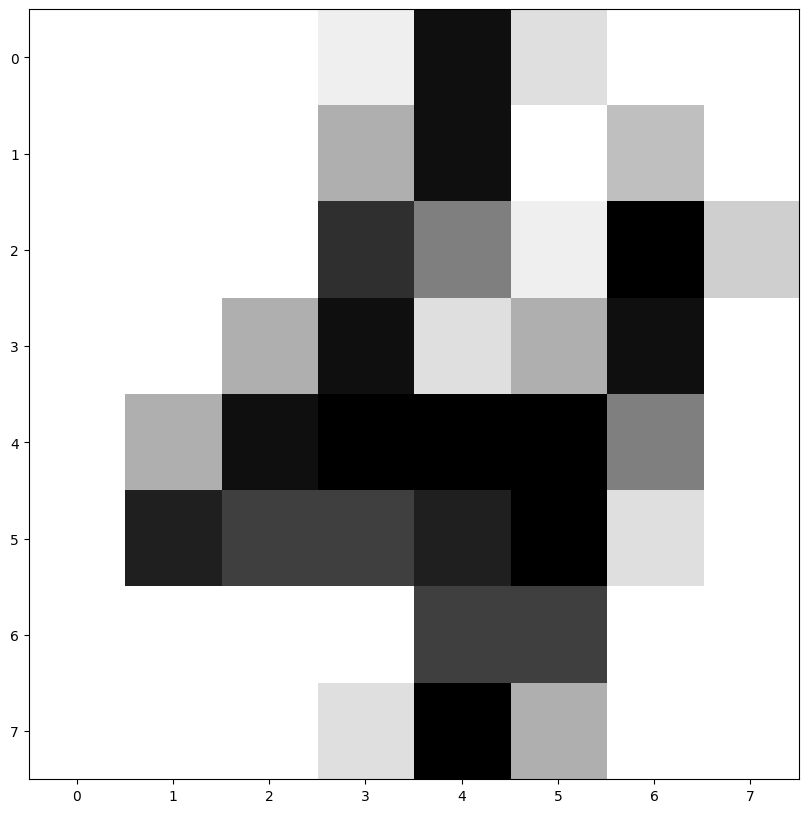

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (18,10)
from matplotlib.pyplot import cm
import seaborn as sns
plt.gray()
plt.imshow(digits.images[1001], cmap=plt.cm.gray_r)

In [ ]:
from sklearn import decomposition
pca_2D = decomposition.PCA(n_components=2)
pca_2D.fit(X)
z1 = pca_2D.transform(X)

In [ ]:
z1.shape


(1797, 2)

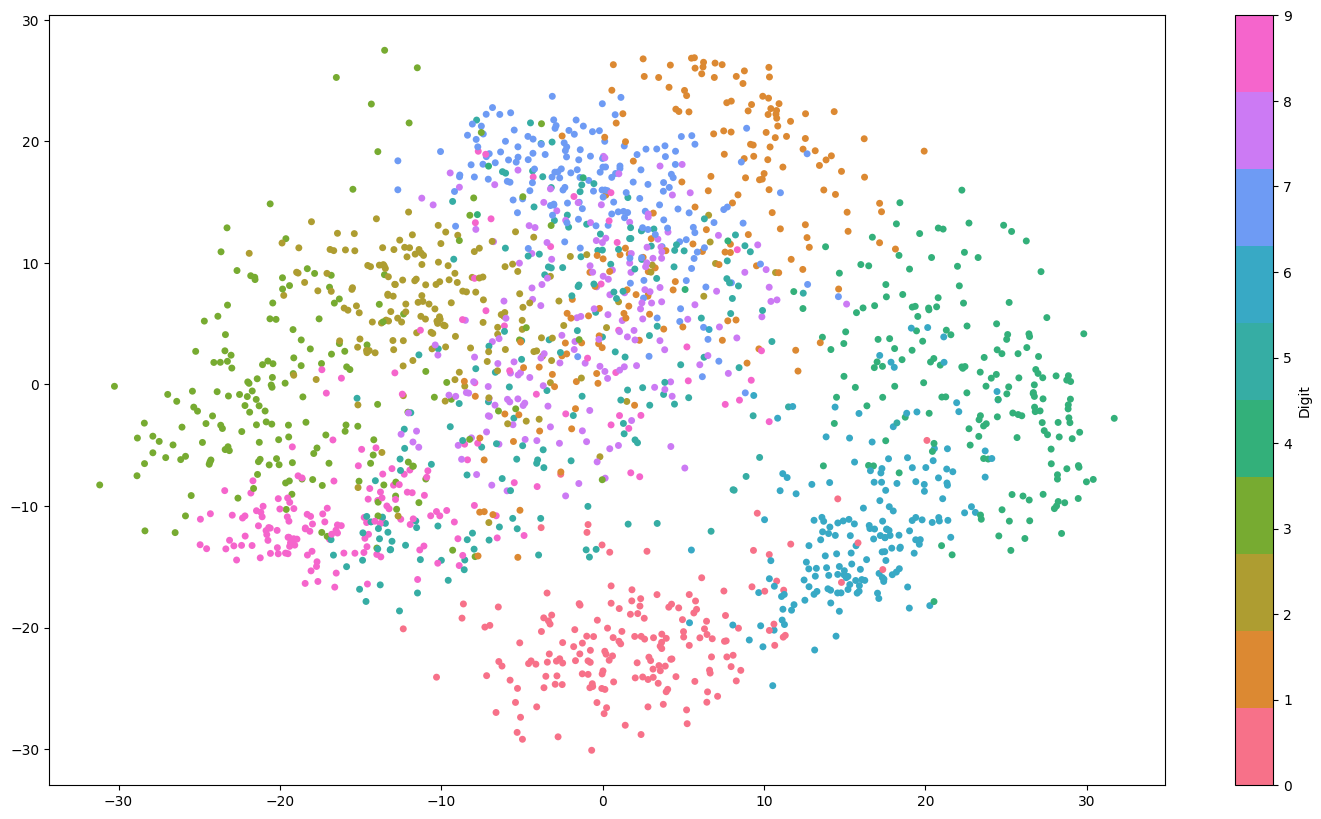

In [ ]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(sns.husl_palette(len(np.unique(Y))))
fig, ax = plt.subplots()

"""
  on x-axis we use 0th dimension of z1
  on y-axis we use 1th dimension of z2
"""

im = ax.scatter(z1[:,0], z1[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')

### Two PCA components can only expplain 28% of variance of origional data

In [ ]:
pca_2D.explained_variance_ratio_.sum()

np.float64(0.28509364823699285)

In [ ]:
#Select 12 PCA
%%time
pca_12D = decomposition.PCA(n_components=12)
pca_12D.fit(X)
z12 = pca_12D.transform(X)
z12.shape

CPU times: user 14.1 ms, sys: 0 ns, total: 14.1 ms
Wall time: 16.5 ms


(1797, 12)

In [ ]:
pca_12D.explained_variance_ratio_.sum()

np.float64(0.7846771429740798)

###12 PCA components can explain 78% of variance of origional data

In [ ]:
pca_12D.explained_variance_ratio_

array([0.14890594, 0.13618771, 0.11794594, 0.08409979, 0.05782415,
       0.0491691 , 0.04315987, 0.03661373, 0.03353248, 0.03078806,
       0.02372341, 0.02272697])

###TSNE

In [47]:
%%time
from sklearn.manifold import TSNE
z_tsne = TSNE(n_components=2, random_state=0).fit_transform(X)
z_tsne

CPU times: user 17.5 s, sys: 13.9 ms, total: 17.5 s
Wall time: 21.2 s


array([[ -3.0067863, -54.082108 ],
       [ 10.148858 ,  12.127184 ],
       [-14.086472 ,  19.052633 ],
       ...,
       [ -6.099084 ,  11.091121 ],
       [-21.304056 , -15.324477 ],
       [-14.31428  ,   7.27293  ]], dtype=float32)

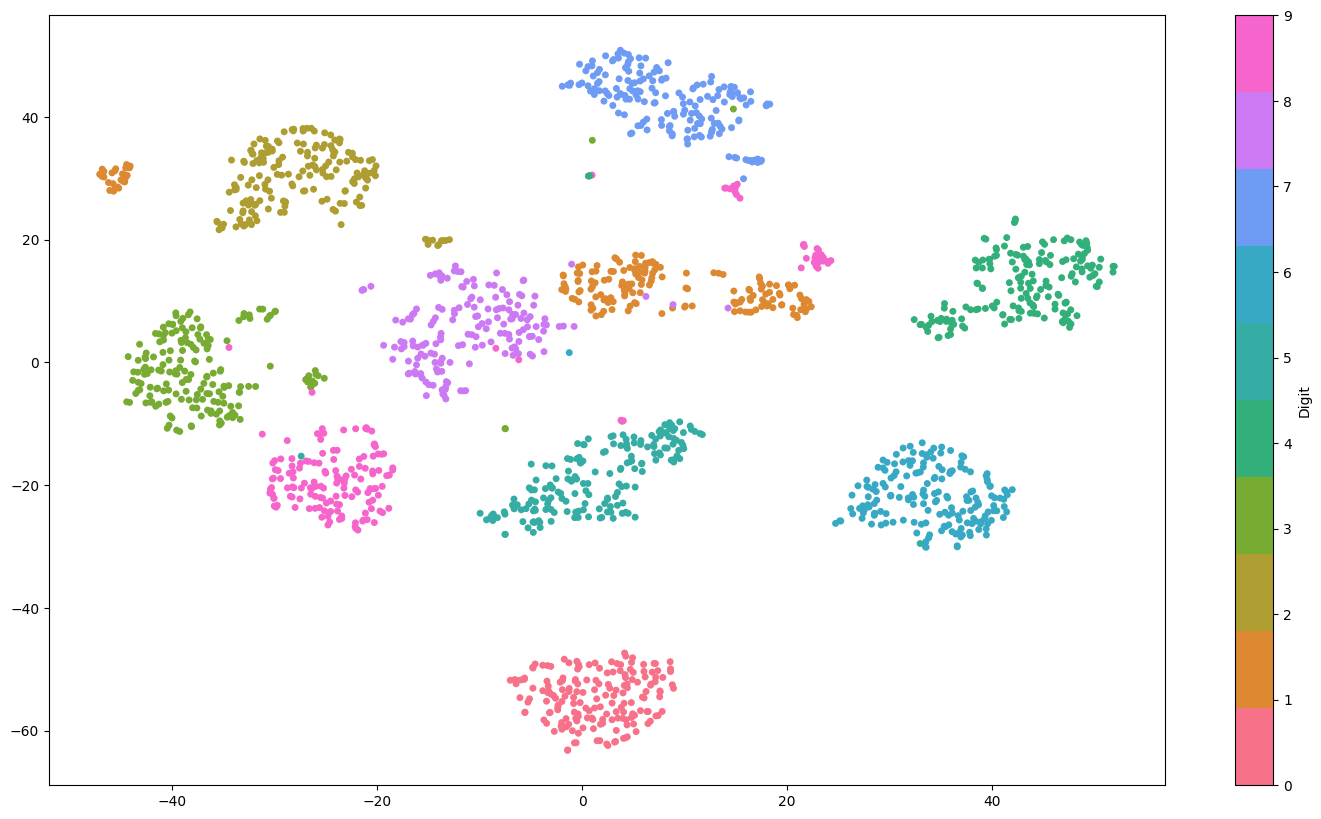

In [46]:
fig, ax = plt.subplots()
im = ax.scatter(z_tsne[:,0], z_tsne[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')

###TSNE has performed better with clear separation which is expected from TSNE as it captures the distance after projection of origional dat onto the PC

#UMAP


In [51]:
from umap import UMAP
Z3 = UMAP(init='random', random_state=42).fit_transform(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



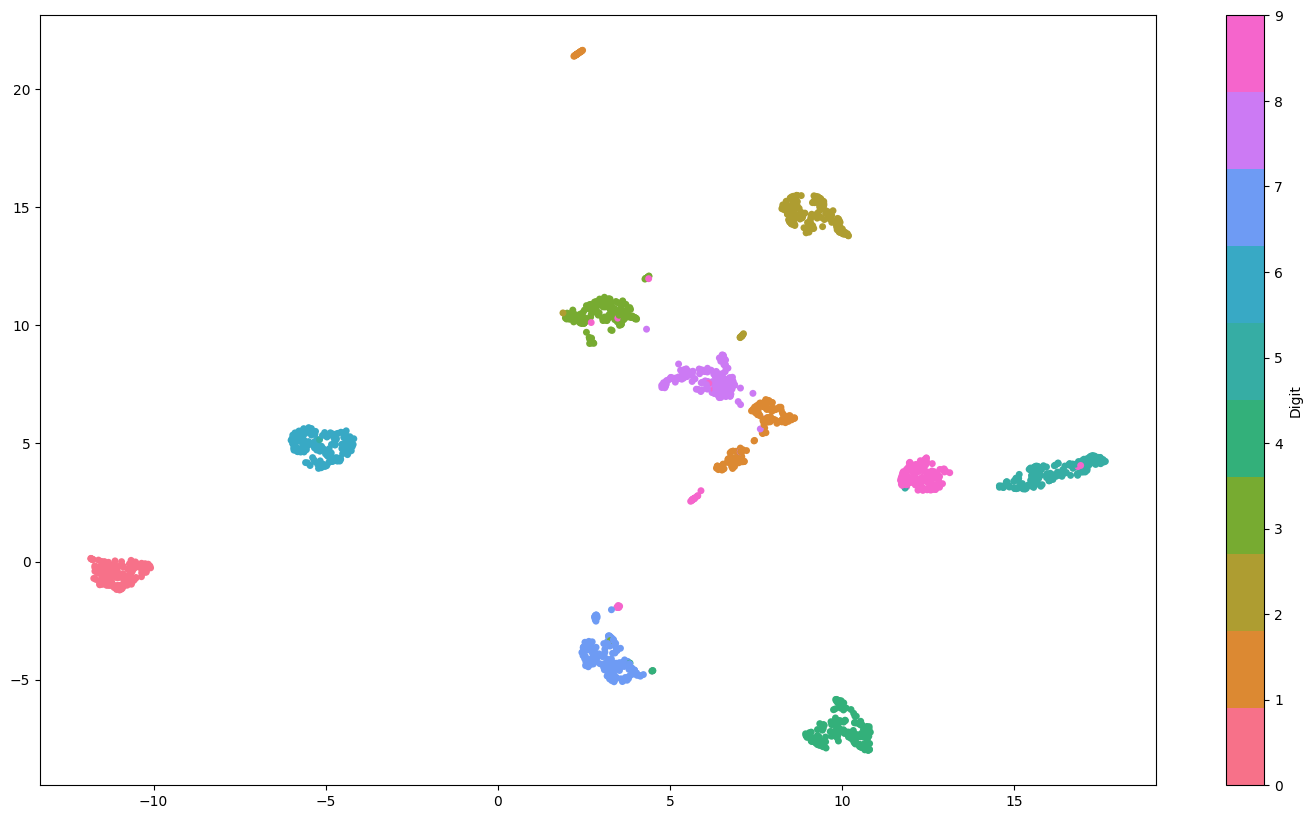

In [52]:
fig, ax = plt.subplots()
im = ax.scatter(Z3[:,0], Z3[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')